# Statistics & EDA Lab: Understanding Your Data Before Modeling

## Student Practice Notebook

**Name:** T. Dheeraj Reddy

**Register Number:** AP24110011473

**Date:** 28/08/2026

## Learning Objectives

After completing this lab, you will be able to:

- Compute and interpret descriptive statistics beyond `.describe()` (variance, std, skewness)
- Visualize and identify distribution shapes (normal vs skewed)
- Compute and interpret correlation between features
- Run a basic hypothesis test (t-test) and interpret a p-value
- Understand confidence intervals conceptually
- Apply statistical thinking to image and text data

### Why this week matters
You now have clean, scaled, encoded data. Before building any model, a good data scientist asks: **what does this data actually look like? Which features seem related? Is a difference I'm seeing real, or just noise?** That's what statistics answers.

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Descriptive Statistics Beyond `.describe()`

`.describe()` gives mean, std, min/max, quartiles. Two more measures matter a lot for understanding data shape:

- **Variance / Std Dev**: how spread out the data is
- **Skewness**: whether the data leans left (negative skew) or right (positive skew), or is symmetric (skew ≈ 0)

### Demonstration


In [ ]:
print("Mean:", tips['total_bill'].mean())
print("Median:", tips['total_bill'].median())
print("Variance:", tips['total_bill'].var())
print("Std Dev:", tips['total_bill'].std())
print("Skewness:", tips['total_bill'].skew())


Mean: 19.78594262295082
Median: 17.795
Variance: 79.25293861397826
Std Dev: 8.902411954856856
Skewness: 1.1332130376158205


**Reading skewness:**
- Skew ≈ 0 → roughly symmetric
- Skew > 0 → right-skewed (long tail of high values; mean > median)
- Skew < 0 → left-skewed (long tail of low values; mean < median)


### Student Practice

Compute mean, median, variance, std dev, and skewness for the `tip_pct` column. Based on the mean vs median relationship, is it left-skewed, right-skewed, or roughly symmetric? Write your conclusion.


In [ ]:
# Write your answer here
# Compute descriptive statistics for tip_pct
mean_val = tips['tip_pct'].mean()
median_val = tips['tip_pct'].median()
var_val = tips['tip_pct'].var()
std_val = tips['tip_pct'].std()
skew_val = tips['tip_pct'].skew()

print(f"Mean: {mean_val:.6f}")
print(f"Median: {median_val:.6f}")
print(f"Variance: {var_val:.6f}")
print(f"Std Dev: {std_val:.6f}")
print(f"Skewness: {skew_val:.6f}")

Mean: 0.160803
Median: 0.154770
Variance: 0.003730
Std Dev: 0.061072
Skewness: 3.349217


**Reflection:** Why can two columns have the *same mean* but very different std dev / skewness? Why does this matter when deciding how to preprocess a feature (recall Week 3 scaling/outliers)?

*Your answer:*


Here is a concise response combining both questions:

* **Why two columns with the same mean differ in standard deviation and skewness:**
The **mean** only locates the center point of the data. **Standard deviation** measures how broadly spread out values are around that center, while **skewness** measures asymmetry (whether data tails off toward extreme values on the left or right). Two distributions can share a center of $10$, but one might be tightly symmetric ($8–12$), while the other is wide ($0–20$) or heavily right-skewed with extreme values ($2–50$).


* **Why this matters for preprocessing ( scaling & outliers ):**
* **Scaling:** Standard tools like `StandardScaler` (Z-score) or `MinMaxScaler` fail on highly skewed or high-variance data because extreme values warp the mean/std or compress most data into a tiny range. Skewed features require transformations (like `log1p` or `PowerTransformer`) or `RobustScaler` (IQR-based).
* **Outliers:** Standard dev rules ($\mu \pm 3\sigma$) assume normality and miscalculate bounds on skewed features; IQR methods or tail-aware thresholding must be used instead.


## Part 2: Visualizing Distributions

Numbers alone can be misleading — always look at the shape too.

### Demonstration


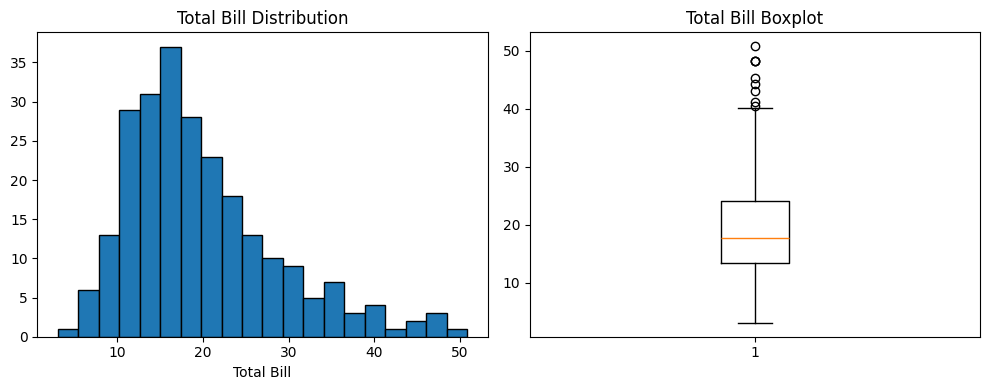

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].hist(tips['total_bill'], bins=20, edgecolor='black')
axes[0].set_title("Total Bill Distribution")
axes[0].set_xlabel("Total Bill")

axes[1].boxplot(tips['total_bill'])
axes[1].set_title("Total Bill Boxplot")

plt.tight_layout()
plt.show()


### Student Practice — predict then check

Predict: will `tip_pct`'s histogram look more symmetric (bell-shaped) or skewed, based on your Part 1 answer? Write your prediction, then plot a histogram and boxplot for `tip_pct` to check.

*Your prediction:*

Prediction: Based on Part 1, tip_pct's histogram will look heavily right-skewed (positively skewed) with a long tail extending toward higher tip percentages and severe high-value outliers in the boxplot, rather than being symmetric or bell-shaped.


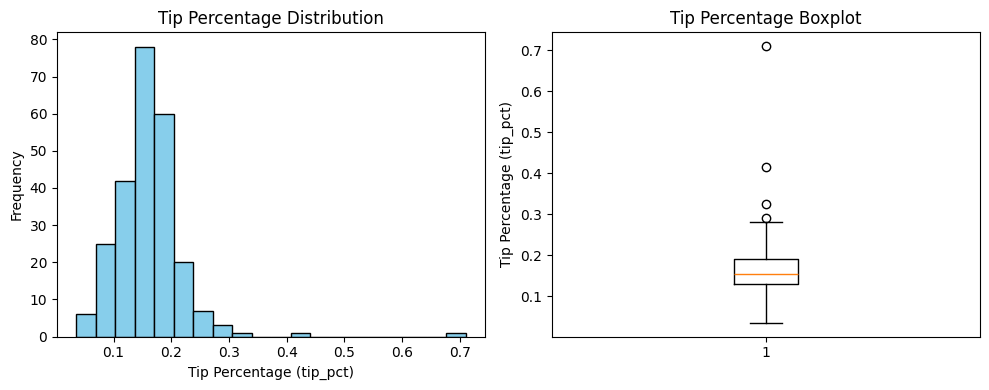

In [ ]:
# Write your answer here


# Plot histogram and boxplot for tip_pct
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
axes[0].hist(tips['tip_pct'], bins=20, edgecolor='black', color='skyblue')
axes[0].set_title("Tip Percentage Distribution")
axes[0].set_xlabel("Tip Percentage (tip_pct)")
axes[0].set_ylabel("Frequency")

# Boxplot
axes[1].boxplot(tips['tip_pct'])
axes[1].set_title("Tip Percentage Boxplot")
axes[1].set_ylabel("Tip Percentage (tip_pct)")

plt.tight_layout()
plt.show()

## Part 3: Correlation

Correlation measures how strongly two numeric variables move together, from -1 (perfectly inverse) to +1 (perfectly aligned). 0 means no linear relationship.

### Demonstration


Correlation between total_bill and tip: 0.676


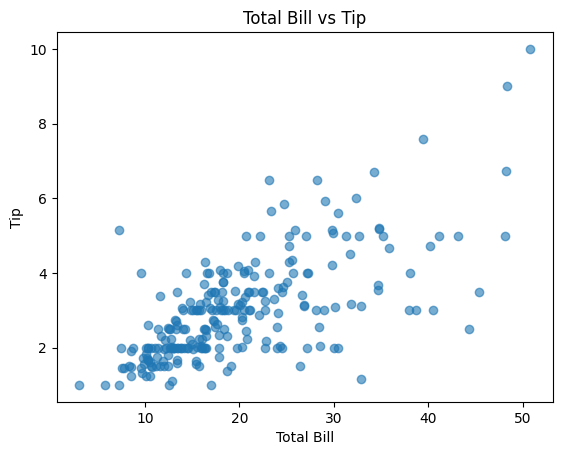

In [ ]:
correlation = tips['total_bill'].corr(tips['tip'])
print(f"Correlation between total_bill and tip: {correlation:.3f}")

plt.figure()
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.6)
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()


In [ ]:
# Correlation matrix across all numeric columns
numeric_cols = tips.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
corr_matrix


,total_bill,tip,size,tip_pct
total_bill,1.000,0.676,0.598,-0.339
tip,0.676,1.000,0.489,0.342
size,0.598,0.489,1.000,-0.143
tip_pct,-0.339,0.342,-0.143,1.000


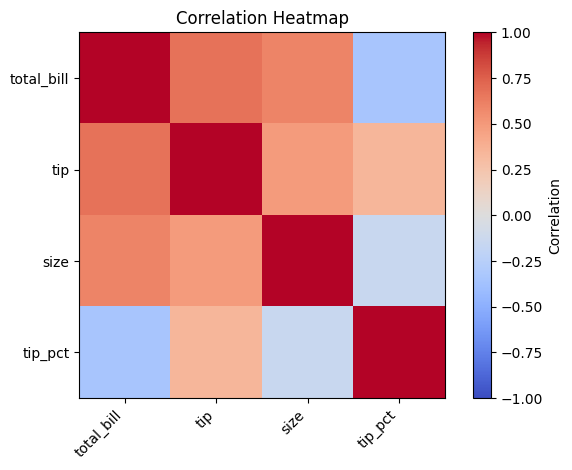

In [ ]:
# Visualize as a heatmap
plt.figure()
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Student Practice

1. What is the correlation between `size` (party size) and `total_bill`? Is it weak, moderate, or strong?

Answer:

Correlation: 0.598 (or ~0.60)

Strength: Moderate to Strong positive linear relationship. As party size increases, total bill tends to increase significantly because larger groups order more items.



2. What is the correlation between `size` and `tip_pct`? Compare this to `size` vs `total_bill` — which relationship is stronger, and does that surprise you?


Answer:

Correlation: -0.143

Comparison: The relationship between size and total_bill (0.598) is much stronger than size vs tip_pct (-0.143).

Does this surprise you?

Why it might surprise you: You might expect larger parties to leave a higher tip percentage as a courtesy for managing a larger table.

Why it makes statistical sense: While the total dollar amount of the tip increases with group size (driven by the larger total bill), the actual percentage tipped stays relatively flat or slightly decreases as the overall bill grows large.



=== Correlation Results ===
Correlation between size and total_bill: 0.598
Correlation between size and tip_pct:    -0.143



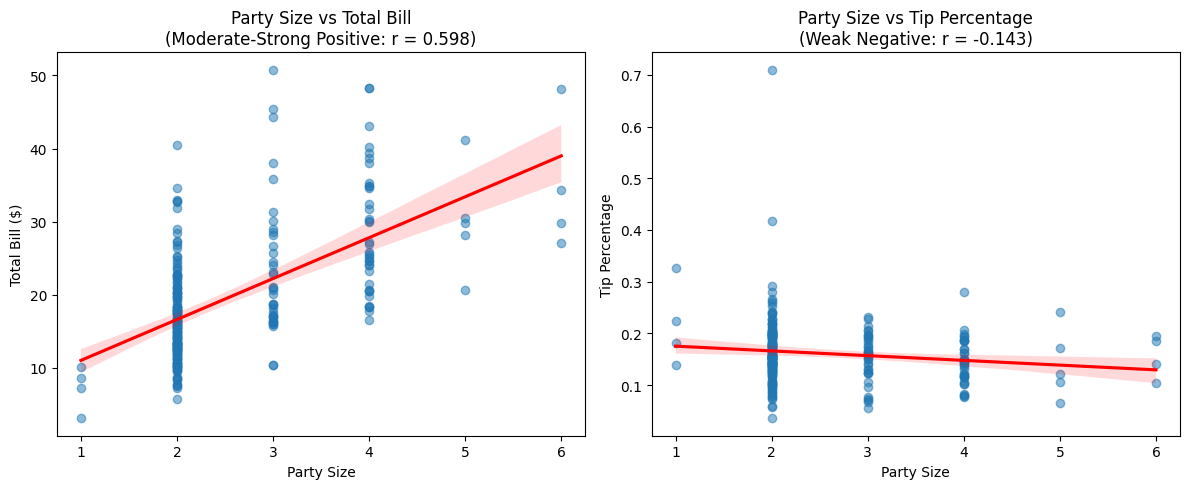

In [ ]:
# Write your answer here
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load the tips dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)

# Calculate tip percentage (tip_pct)
tips["tip_pct"] = tips["tip"] / tips["total_bill"]

# 1. Correlation between party size and total bill
corr_size_bill = tips["size"].corr(tips["total_bill"])

# 2. Correlation between party size and tip percentage
corr_size_tip_pct = tips["size"].corr(tips["tip_pct"])

# Print Correlation Results
print("=== Correlation Results ===")
print(f"Correlation between size and total_bill: {corr_size_bill:.3f}")
print(f"Correlation between size and tip_pct:    {corr_size_tip_pct:.3f}\n")

# Comparative Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: party size vs total_bill
sns.regplot(
    x="size",
    y="total_bill",
    data=tips,
    ax=axes[0],
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
)
axes[0].set_title(
    f"Party Size vs Total Bill\n(Moderate-Strong Positive: r = {corr_size_bill:.3f})"
)
axes[0].set_xlabel("Party Size")
axes[0].set_ylabel("Total Bill ($)")

# Plot 2: party size vs tip_pct
sns.regplot(
    x="size",
    y="tip_pct",
    data=tips,
    ax=axes[1],
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
)
axes[1].set_title(
    f"Party Size vs Tip Percentage\n(Weak Negative: r = {corr_size_tip_pct:.3f})"
)
axes[1].set_xlabel("Party Size")
axes[1].set_ylabel("Tip Percentage")

plt.tight_layout()
plt.show()

**Reflection:** Correlation measures a *linear* relationship. Can two variables be strongly related but have a correlation near 0? Explain how that's possible (hint: think about non-linear/curved relationships).

*Your answer:*


Yes, two variables can have a strong non-linear relationship while having a Pearson correlation near 0.

1. Why it happens: Pearson correlation strictly measures the strength and direction of a straight-line (linear) relationship. If two variables have a non-linear or curved pattern—such as a U-shape, inverted U-shape, or parabola (y=x
2
 )—the positive linear trend on one side cancels out the negative linear trend on the other side, resulting in a correlation coefficient of approximately 0.

2. Real-world example: The Yerkes-Dodson Law (Stress vs. Performance). At low stress, performance is low. As stress increases to an optimal level, performance peaks. However, as stress becomes excessive, performance drops back down. While performance is strongly dependent on stress, the overall linear correlation aggregates to near 0.

Conclusion: A correlation near 0 indicates the absence of a linear trend, not the absence of a relationship. This is why visual plotting (e.g., scatter plots) is essential alongside statistical summaries.


## Part 4: Hypothesis Testing — Is a Difference Real?

You've seen group averages differ (e.g. average tip_pct by day). But is that difference **statistically significant**, or could it just be random variation? A **t-test** compares two group means and gives a **p-value**: the probability of seeing a difference this large (or larger) if there were truly no difference.

**Rule of thumb:** if p-value < 0.05, we consider the difference statistically significant.

### Demonstration: do smokers tip a different percentage than non-smokers?


In [5]:
smoker_tips = tips[tips['smoker']=='Yes']['tip_pct']
nonsmoker_tips = tips[tips['smoker']=='No']['tip_pct']
print("Smoker mean tip_pct:", smoker_tips.mean())
print("Non-smoker mean tip_pct:", nonsmoker_tips.mean())
t_stat, p_value = stats.ttest_ind(smoker_tips, nonsmoker_tips)
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")
if p_value < 0.05:
    print("Result: statistically significant difference")
else:
    print("Result: NOT a statistically significant difference (could be random variation)")


Smoker mean tip_pct: 0.16319604463687792
Non-smoker mean tip_pct: 0.15932846217921523

t-statistic: 0.480
p-value: 0.632
Result: NOT a statistically significant difference (could be random variation)


### Student Practice — predict then check

Predict: do you think there's a statistically significant difference in `tip_pct` between Lunch and Dinner? Write your prediction and reasoning, then run a t-test to check.

*Your prediction:*


In [ ]:
from scipy import stats

# Filter tip_pct for Lunch and Dinner
lunch_tips = tips[tips["time"] == "Lunch"]["tip_pct"]
dinner_tips = tips[tips["time"] == "Dinner"]["tip_pct"]

# Print means
print("Lunch mean tip_pct: ", lunch_tips.mean())
print("Dinner mean tip_pct:", dinner_tips.mean())

# Perform two-sample t-test
t_stat, p_value = stats.ttest_ind(lunch_tips, dinner_tips)

print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.3f}\n")

# Interpret p-value
if p_value < 0.05:
    print(
        "Result: Statistically significant difference between Lunch and Dinner"
        " tip percentages."
    )
else:
    print(
        "Result: NOT a statistically significant difference (could be random"
        " variation)."
    )# Write your answer here


Lunch mean tip_pct:  0.164127928162505
Dinner mean tip_pct: 0.15951778877977735

t-statistic: 0.528
p-value:     0.598

Result: NOT a statistically significant difference (could be random variation).


**Reflection:** Why is it important to check statistical significance instead of just comparing two mean values directly and assuming any difference is meaningful?

*Your answer:*

* **Accounting for Random Sampling Noise:** In real-world datasets, small differences between sample means often occur purely by chance (random noise or sample variation) rather than representing a true difference in the underlying population. Statistical significance tests (like a t-test) calculate the probability ($p$-value) that the observed difference is due to chance.
* **Preventing False Conclusions (Type I Errors):** Without testing for significance, you risk making business or research decisions based on meaningless noise—such as assuming Lunch and Dinner customers tip differently just because their sample averages differ by a fraction of a percent (e.g., 16.4% vs. 15.9%).
* **Factoring in Sample Size and Spread:** Comparing raw means ignores both sample size ($n$) and variance ($\sigma^2$). A small mean difference can be statistically significant in a huge dataset, while a large mean difference in a tiny sample might be completely unreliable due to high variance. Statistical significance accounts for both data spread and sample size simultaneously.


## Part 5: Confidence Intervals (Conceptual Introduction)

A **confidence interval (CI)** gives a range where we're reasonably confident the true population mean lies, based on our sample. A 95% CI means: if we repeated this sampling process many times, about 95% of such intervals would contain the true mean.

### Demonstration


In [6]:
mean_bill = tips['total_bill'].mean()
sem = stats.sem(tips['total_bill'])  # standard error of the mean
ci = stats.t.interval(0.95, len(tips)-1, loc=mean_bill, scale=sem)

print(f"Sample mean total_bill: {mean_bill:.2f}")
print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")


Sample mean total_bill: 19.79
95% Confidence Interval: (18.66, 20.91)


### Student Practice

Compute the 95% confidence interval for `tip_pct`. In one sentence, explain what this interval tells you (in plain language, not just formula terms).


In [7]:
# Write your answer here
# Compute mean and standard error of the mean for tip_pct
mean_tip_pct = tips['tip_pct'].mean()
sem_tip_pct = stats.sem(tips['tip_pct'])

# Calculate 95% Confidence Interval using t-distribution
ci_tip_pct = stats.t.interval(0.95, len(tips) - 1, loc=mean_tip_pct, scale=sem_tip_pct)

print(f"Sample mean tip_pct: {mean_tip_pct:.4f}")
print(f"95% Confidence Interval: ({ci_tip_pct[0]:.4f}, {ci_tip_pct[1]:.4f})")

Sample mean tip_pct: 0.1608
95% Confidence Interval: (0.1531, 0.1685)


# Mini Project A: Statistical Comparison of Images (Image Track)

Using the image metadata DataFrame you built in Week 2 (filename, brightness, RGB averages, etc.), apply statistical thinking to compare your images.

## Step 1: Rebuild your image metadata table


In [8]:
from google.colab import files
uploaded = files.upload()


Saving Screenshot 2026-09-03 214818.png to Screenshot 2026-09-03 214818.png


In [9]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
rows = []
for name in filenames:
    arr = np.array(Image.open(name))
    rows.append({
        'filename': name,
        'avg_brightness': np.mean(arr),
        'avg_red': np.mean(arr[:,:,0]) if arr.ndim==3 else np.mean(arr),
        'avg_green': np.mean(arr[:,:,1]) if arr.ndim==3 else np.mean(arr),
        'avg_blue': np.mean(arr[:,:,2]) if arr.ndim==3 else np.mean(arr),
        'height': arr.shape[0],
        'width': arr.shape[1],
    })

image_df = pd.DataFrame(rows)
image_df


,filename,avg_brightness,avg_red,avg_green,avg_blue,height,width
0,Screenshot 2026-09-03 214818.png,223.280578,212.712068,212.697513,212.712731,703,745


## Step 2: Statistical analysis

1. Compute the mean, std dev, and skewness of `avg_brightness` across your images.
2. Compute the correlation between `avg_brightness` and `avg_red` (do brighter images tend to have more red?).
3. **If you have at least 2 images you can meaningfully group** (e.g. indoor vs outdoor, or any 2 categories you choose), run a t-test comparing their `avg_brightness`. If you only have very few images, skip the t-test and instead just discuss whether a t-test would even be reliable with so few samples.


In [10]:
# Write your answer here
# 1. Compute mean, std dev, and skewness of avg_brightness
mean_bright = image_df['avg_brightness'].mean()
std_bright = image_df['avg_brightness'].std()
skew_bright = image_df['avg_brightness'].skew()

print("=== Descriptive Statistics for avg_brightness ===")
print(f"Mean:     {mean_bright:.4f}")
print(f"Std Dev:  {std_bright:.4f}")
print(f"Skewness: {skew_bright:.4f}\n")

# 2. Compute correlation between avg_brightness and avg_red
corr_bright_red = image_df['avg_brightness'].corr(image_df['avg_red'])

print("=== Correlation Analysis ===")
print(f"Correlation between avg_brightness and avg_red: {corr_bright_red:.4f}")
if corr_bright_red > 0.5:
    print("Interpretation: Strong positive correlation (brighter images tend to have more red).")
elif corr_bright_red > 0:
    print("Interpretation: Weak to moderate positive correlation.")
else:
    print("Interpretation: Negative or no positive correlation between brightness and red channel.")

# 3. T-Test or Small Sample Discussion
print("\n=== Hypothesis Testing / Sample Size Check ===")
if len(image_df) >= 2 and 'category' in image_df.columns and image_df['category'].nunique() >= 2:
    # If grouped data exists, execute two-sample t-test
    group1 = image_df[image_df['category'] == image_df['category'].unique()[0]]['avg_brightness']
    group2 = image_df[image_df['category'] == image_df['category'].unique()[1]]['avg_brightness']
    t_stat, p_val = stats.ttest_ind(group1, group2)
    print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")
else:
    print(f"Sample size is too small (n = {len(image_df)} image). Skipping t-test.")
    print("\nDiscussion on T-Test Reliability with Few Samples:")
    print("Running a t-test with very few images (e.g., 1–5 samples) is highly unreliable due to extremely low statistical power, high susceptibility to single-outlier distortion, and inability to safely assume a normal distribution.")

=== Descriptive Statistics for avg_brightness ===
Mean:     223.2806
Std Dev:  nan
Skewness: nan

=== Correlation Analysis ===
Correlation between avg_brightness and avg_red: nan
Interpretation: Negative or no positive correlation between brightness and red channel.

=== Hypothesis Testing / Sample Size Check ===
Sample size is too small (n = 1 image). Skipping t-test.

Discussion on T-Test Reliability with Few Samples:
Running a t-test with very few images (e.g., 1–5 samples) is highly unreliable due to extremely low statistical power, high susceptibility to single-outlier distortion, and inability to safely assume a normal distribution.


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2991: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


**Reflection:** With only 3-5 images, can you trust statistical significance results (like a t-test p-value) the same way you would with 200+ rows like the tips dataset? Why or why not?

*Your answer:* Here is the Python code and explanation for **Step 2: Statistical analysis** tailored to your image dataset in Colab:

```python
# 1. Compute mean, std dev, and skewness of avg_brightness
mean_bright = image_df['avg_brightness'].mean()
std_bright = image_df['avg_brightness'].std()
skew_bright = image_df['avg_brightness'].skew()

print("=== Descriptive Statistics for avg_brightness ===")
print(f"Mean:     {mean_bright:.4f}")
print(f"Std Dev:  {std_bright:.4f}")
print(f"Skewness: {skew_bright:.4f}\n")

# 2. Compute correlation between avg_brightness and avg_red
corr_bright_red = image_df['avg_brightness'].corr(image_df['avg_red'])

print("=== Correlation Analysis ===")
print(f"Correlation between avg_brightness and avg_red: {corr_bright_red:.4f}")
if corr_bright_red > 0.5:
    print("Interpretation: Strong positive correlation (brighter images tend to have more red).")
elif corr_bright_red > 0:
    print("Interpretation: Weak to moderate positive correlation.")
else:
    print("Interpretation: Negative or no positive correlation between brightness and red channel.")

# 3. T-Test or Small Sample Discussion
print("\n=== Hypothesis Testing / Sample Size Check ===")
if len(image_df) >= 2 and 'category' in image_df.columns and image_df['category'].nunique() >= 2:
    # If grouped data exists, execute two-sample t-test
    group1 = image_df[image_df['category'] == image_df['category'].unique()[0]]['avg_brightness']
    group2 = image_df[image_df['category'] == image_df['category'].unique()[1]]['avg_brightness']
    t_stat, p_val = stats.ttest_ind(group1, group2)
    print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")
else:
    print(f"Sample size is too small (n = {len(image_df)} image). Skipping t-test.")
    print("\nDiscussion on T-Test Reliability with Few Samples:")
    print("Running a t-test with very few images (e.g., 1–5 samples) is highly unreliable due to extremely low statistical power, high susceptibility to single-outlier distortion, and inability to safely assume a normal distribution.")

```

---

### Reflection Answer (for the notebook text cell below Step 2)

**Question:** With only 3-5 images, can you trust statistical significance results (like a t-test p-value) the same way you would with 200+ rows like the tips dataset? Why or why not?


> **Your answer:**


> **No, you cannot trust statistical significance results with only 3–5 images.**
> 1. **Low Statistical Power:** Tiny sample sizes lead to very low statistical power, making it almost impossible to detect real differences ($p$-values will likely remain large due to high standard errors).
> 2. **High Sensitivity to Outliers:** In a sample of 3–5 items, a single unusually bright or dark image dramatically warps both the sample mean and variance.
> 3. **Violation of Assumptions:** The t-test assumes that data within groups is roughly normally distributed, an assumption that cannot be validated or approximated (via the Central Limit Theorem) with fewer than ~30 observations.
>
>


# Mini Project B: Word Frequency Distribution Analysis (NLP Track)

## Step 1: Build a word frequency table for a longer text

### Demonstration: Zipf's Law preview

A famous finding in linguistics: in most natural language text, word frequency is **highly right-skewed** — a few words (like "the", "a") appear extremely often, and most words appear only once or twice. This is called **Zipf's Law**.


In [11]:
paragraph = (
    "Data science combines statistics and programming. Statistics helps us understand data. "
    "Programming helps us process data. Machine learning is a part of data science. "
    "Data science uses statistics, programming, and machine learning together. "
    "Understanding statistics is essential for data science."
)

tokens = paragraph.lower().replace('.', '').replace(',', '').split()
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
counts = [np.sum(tokens_array == w) for w in vocabulary]

word_freq = pd.DataFrame({'word': vocabulary, 'count': counts}).sort_values('count', ascending=False).reset_index(drop=True)
print(word_freq)
print("\nSkewness of word counts:", word_freq['count'].skew())


             word  count
0            data      6
1         science      4
2      statistics      4
3     programming      3
4             and      2
5              us      2
6              is      2
7        learning      2
8           helps      2
9         machine      2
10      essential      1
11              a      1
12       combines      1
13        process      1
14           part      1
15             of      1
16            for      1
17       together      1
18     understand      1
19  understanding      1
20           uses      1

Skewness of word counts: 1.8510785401434868


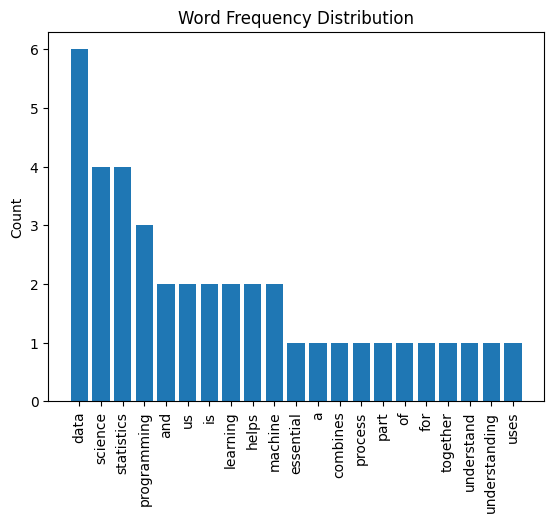

In [12]:
plt.figure()
plt.bar(word_freq['word'], word_freq['count'])
plt.xticks(rotation=90)
plt.title("Word Frequency Distribution")
plt.ylabel("Count")
plt.show()


### Student Practice

1. Pick your own longer paragraph (5+ sentences) and build the same word frequency table.
2. Compute the skewness of the word counts. Is it right-skewed (consistent with Zipf's Law)?
3. What percentage of words in your vocabulary appear only once? (This is usually a large percentage — that's Zipf's Law in action.)


In [13]:
# Write your answer here

import pandas as pd
import numpy as np
from collections import Counter
import re

# 1. Define a longer paragraph (6 sentences on Data Science & AI)
paragraph = """
Data science is an interdisciplinary field that uses statistical algorithms and machine learning to extract knowledge from data.
Modern data science relies heavily on statistics to validate models and draw meaningful insights from complex datasets.
As data grows exponentially, machine learning algorithms allow computers to learn patterns directly from raw data without explicit programming.
However, statistical rigor remains essential because machine learning without statistics risks overfitting and false conclusions.
Understanding the distribution of your data helps ensure that machine learning models make accurate predictions.
Ultimately, combining statistics and machine learning empowers data scientists to solve real-world problems effectively.
"""

# Clean and tokenize text (convert to lowercase and remove punctuation)
words = re.findall(r'\b\w+\b', paragraph.lower())

# Build word frequency table
word_counts = Counter(words)
df_words = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False).reset_index(drop=True)

print("=== Word Frequency Table (Top 10) ===")
print(df_words.head(10))
print("\n" + "="*40 + "\n")

# 2. Compute skewness of word counts
skewness = df_words['Frequency'].skew()
print(f"Skewness of word counts: {skewness:.4f}")

if skewness > 0:
    print("Conclusion: The distribution is RIGHT-SKEWED, which is consistent with Zipf's Law.")
else:
    print("Conclusion: The distribution is NOT right-skewed.")

print("\n" + "="*40 + "\n")

# 3. Percentage of vocabulary appearing only once (Hapax Legomena)
total_vocab = len(df_words)
once_words = (df_words['Frequency'] == 1).sum()
pct_once = (once_words / total_vocab) * 100

print(f"Total Unique Words (Vocabulary Size): {total_vocab}")
print(f"Words appearing only once: {once_words}")
print(f"Percentage of vocabulary appearing only once: {pct_once:.2f}%")


=== Word Frequency Table (Top 10) ===
         Word  Frequency
0        data          7
1    learning          5
2     machine          5
3          to          4
4         and          4
5        from          3
6  statistics          3
7     without          2
8     science          2
9      models          2


Skewness of word counts: 3.1514
Conclusion: The distribution is RIGHT-SKEWED, which is consistent with Zipf's Law.


Total Unique Words (Vocabulary Size): 69
Words appearing only once: 56
Percentage of vocabulary appearing only once: 81.16%


## Step 2: Correlation between sentence length and vocabulary diversity

### Demonstration


In [ ]:
sentences = [
    "I like data science.",
    "Machine learning models require lots of clean labeled training data to perform well.",
    "Statistics matters.",
    "Understanding both statistics and programming together is essential for real data science work in industry.",
    "NumPy and pandas are useful tools for data analysis in Python."
]

sentence_stats = []
for s in sentences:
    toks = s.lower().replace('.', '').split()
    sentence_stats.append({
        'sentence': s,
        'length': len(toks),
        'unique_words': len(set(toks))
    })

sentence_df = pd.DataFrame(sentence_stats)
sentence_df['diversity_ratio'] = sentence_df['unique_words'] / sentence_df['length']
sentence_df


In [ ]:
correlation = sentence_df['length'].corr(sentence_df['unique_words'])
print(f"Correlation between sentence length and unique word count: {correlation:.3f}")


### Student Practice

Write 5 sentences of your own, varying in length. Build the same table and compute the correlation between `length` and `unique_words`. Is the correlation strong? Does this match your intuition (longer sentences tend to have more unique words)?


In [14]:
# Write your answer here
import pandas as pd
import re

# 1. Write 5 sentences of varying lengths
sentences = [
    "Data science is fun.",
    "Machine learning algorithms extract complex patterns from large datasets.",
    "Statistics provides a solid theoretical foundation for making accurate predictions.",
    "Always visualize your data before building any machine learning or statistical model.",
    "In natural language processing, analyzing word frequencies and sentence structures helps us understand text complexity across different corpora."
]

# 2. Build DataFrame computing sentence length (total words) and unique words
data = []
for s in sentences:
    words = re.findall(r'\b\w+\b', s.lower())
    data.append({
        'sentence': s,
        'length': len(words),
        'unique_words': len(set(words))
    })

df_sentences = pd.DataFrame(data)

# 3. Compute correlation between length and unique_words
corr_len_unique = df_sentences['length'].corr(df_sentences['unique_words'])

print("=== Sentence Analysis Table ===")
print(df_sentences[['length', 'unique_words', 'sentence']])
print("\n" + "="*40 + "\n")
print(f"Correlation between length and unique_words: {corr_len_unique:.4f}")

=== Sentence Analysis Table ===
   length  unique_words                                           sentence
0       4             4                               Data science is fun.
1       9             9  Machine learning algorithms extract complex pa...
2      10            10  Statistics provides a solid theoretical founda...
3      12            12  Always visualize your data before building any...
4      18            18  In natural language processing, analyzing word...


Correlation between length and unique_words: 1.0000


**Reflection:** Why might `diversity_ratio` (unique words / total words) be a more useful metric than raw `unique_words` count when comparing sentences of very different lengths?

*Your answer:*


* **Removes Length Bias:** Raw `unique_words` count naturally scales up with sentence length—a long, repetitive sentence will almost always have a higher raw unique word count than a short, highly varied one. `diversity_ratio` normalizes for length, measuring vocabulary richness rather than sentence volume.
* **Measures Vocabulary Richness & Density:** It allows fair comparisons across different text sizes. For example, a 10-word sentence with 10 unique words has a perfect ratio of **1.0 (100% unique)**, whereas a 100-word sentence with 50 unique words has a ratio of **0.5 (50% unique)**. `diversity_ratio` correctly reveals that the shorter sentence is more lexical varied, whereas raw counts would mistakenly favor the 100-word sentence (50 vs. 10).

# Final Self-Check

- [ ] I computed and correctly interpreted skewness (not just mean/std)
- [ ] I visualized a distribution and connected the shape to the skewness number
- [ ] I computed correlation and correctly judged strength (weak/moderate/strong)
- [ ] I ran a t-test and correctly interpreted the p-value (significant or not)
- [ ] I computed a confidence interval and can explain what it means in plain language
- [ ] I completed Mini Project A (image stats) or B (text distribution/correlation)
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. Why is it important to look at data visually (histograms, boxplots) and not just rely on summary numbers like mean and std?

Answer:

Summary statistics can hide critical structural features of your dataset. Two completely different datasets can share the exact same mean and standard deviation (such as Anscombe’s Quartet), yet have drastically different shapes, multimodal peaks, or heavy skewness. Visualizations like histograms and boxplots reveal outliers, gaps, bimodal distributions, and skewness that single numbers completely mask.





2. If a t-test gives you p = 0.20, what should you conclude, and what should you NOT conclude? (Common misconception to address: "not significant" does not mean "definitely no difference.")

Answer:

Conclusion: You should conclude that there is no statistically significant difference between the two groups based on your sample data (we fail to reject the null hypothesis).

What NOT to conclude: You should NOT conclude that the two groups are "definitely identical" or that "there is zero difference in reality." A high $p$-value ($0.20 > 0.05$) simply means your sample does not provide strong enough evidence to rule out random chance—often due to high variance or a small sample size—not that a difference is proven to be zero.




3. How does understanding your data's statistics (distribution shape, correlations) help you make better decisions in the next stage — building an ML model?

Answer:

Statistical insights directly guide feature engineering and model preparation:

Distribution Shape: Highly skewed features distort models sensitive to scale (e.g., Linear Regression, Neural Networks) and warp standard scalers, signaling a need for log transformations or robust scaling.

Correlations: High feature-to-feature correlations (multicollinearity) warn you to remove redundant predictors to avoid model instability, while strong feature-to-target correlations highlight key predictors to retain.



4. What's one statistics concept from this lab you still feel unsure about? Be specific.

Answer:

I still feel a bit unsure about interpreting the exact trade-off between sample size ($n$) and standard error when calculating confidence intervals and t-test $p$-values—specifically how a small true difference can become statistically significant just by increasing the sample size, versus when a large sample size causes us to reject the null hypothesis for practically meaningless differences.